In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")


In [21]:
df = pd.read_csv('exctraction_crystallizer (1)\exctraction_crystallizer.csv') 
mapping = pd.read_excel(
    '826-Crystallizer Mapping-TEN-Officiel.xlsx'
)

df.head()


,Unnamed: 0,Tag,Value,Measure_Date,nom de campagne
0,0,826LR06,1.24,2025-08-28 23:00:44,Kampagne 5
1,1,826LR06,1.24,2025-08-28 23:00:45,Kampagne 5
2,2,826LR06,1.24,2025-08-28 23:00:46,Kampagne 5
3,3,826LR06,1.24,2025-08-28 23:00:47,Kampagne 5
4,4,826LR06,1.25,2025-08-28 23:00:48,Kampagne 5


In [22]:
df["Measure_Date"] = pd.to_datetime(df["Measure_Date"])

df = df.drop_duplicates()

df = df.sort_values("Measure_Date")

print(df.isna().sum())

df = df.dropna(subset=["Value"])


Unnamed: 0         0
Tag                0
Value              0
Measure_Date       0
nom de campagne    0
dtype: int64


In [23]:
df = df.merge(
    mapping,
    left_on="Tag",
    right_on="Instrument TAG ID",
    how="left"
)

df.head()


,Unnamed: 0,Tag,Value,Measure_Date,nom de campagne,Equipement Type,Equipement TAG IG,Instrument TAG ID,Instrument Description,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,4197109,826LR05,-0.03,2025-08-27 11:00:45,Kampagne 5,CRYSTALLIZER 2,U-82601-02,826LR05,% of level,NaN,NaN,NaN,NaN
1,4130174,826LR06,1.13,2025-08-27 11:00:45,Kampagne 5,CRYSTALLIZER 3,U-82601-03,826LR06,% of level,NaN,NaN,NaN,NaN
2,4130175,826LR06,1.13,2025-08-27 11:00:46,Kampagne 5,CRYSTALLIZER 3,U-82601-03,826LR06,% of level,NaN,NaN,NaN,NaN
3,4197114,826LR05,-0.03,2025-08-27 11:00:46,Kampagne 5,CRYSTALLIZER 2,U-82601-02,826LR05,% of level,NaN,NaN,NaN,NaN
4,4129414,826FQR23,-4.07,2025-08-27 11:00:46,Kampagne 5,Common 826,NaN,826FQR23,Feed flow meter for all crystallizers,NaN,NaN,NaN,NaN


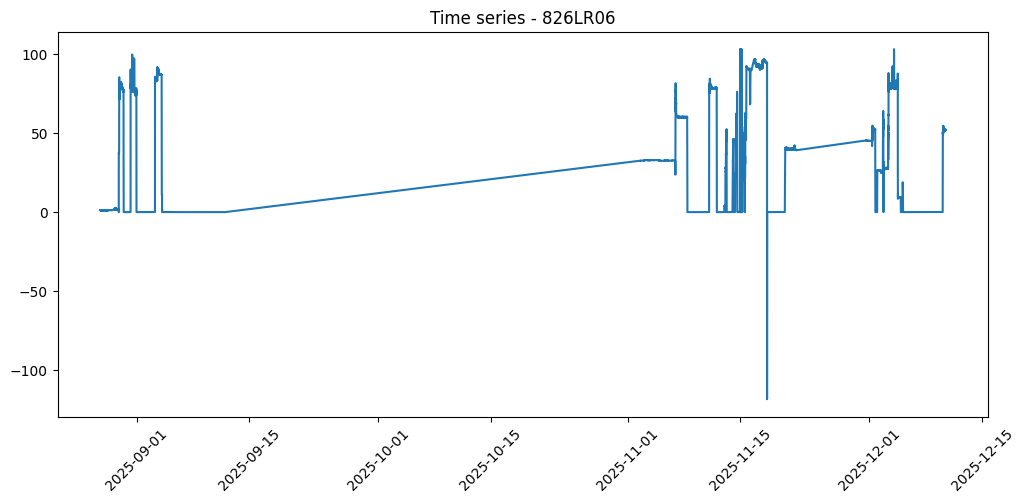

In [24]:
tag_example = "826LR06"

subset = df[df["Tag"] == tag_example]

plt.figure(figsize=(12,5))
plt.plot(subset["Measure_Date"], subset["Value"])
plt.title(f"Time series - {tag_example}")
plt.xticks(rotation=45)
plt.show()


In [25]:

df_pivot = df.pivot_table(
    index="Measure_Date",
    columns="Tag",
    values="Value"
)

df_pivot = df_pivot.sort_index()

df_pivot.head()


Tag,826FQR23,826LR05,826LR06,826TRC07,826TRC07_DeltaT,826TRC08,826TRC08_DeltaT,826TRC09,826TRC09_DeltaT,826XV01,826XV14,826XV16,826XV18,P-82601
Measure_Date,,,,,,,,,,,,,,
2025-08-27 11:00:45,NaN,-0.03,1.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-27 11:00:46,-4.07,-0.03,1.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-27 11:00:47,-4.03,-0.03,1.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-27 11:00:48,-4.07,-0.03,1.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-08-27 11:00:49,-3.87,-0.03,1.13,25.93,0.0,25.72,0.0,25.45,0.0,NaN,NaN,NaN,NaN,NaN


In [26]:

df_pivot = df_pivot.interpolate(method="time")

df_pivot = df_pivot.fillna(method="ffill")

df_pivot = df_pivot.fillna(method="bfill")

print(df_pivot.isna().sum().sum())


0


## FEATURE ENGINEERING TEMPOREL

In [27]:
df_features = df_pivot.copy()

df_diff = df_pivot.diff().add_suffix("_diff")

df_roll = df_pivot.rolling(window=5).mean().add_suffix("_rollmean")

df_features = pd.concat([df_features, df_diff, df_roll], axis=1)

df_features = df_features.dropna()

df_features.head()


Tag,826FQR23,826LR05,826LR06,826TRC07,826TRC07_DeltaT,826TRC08,826TRC08_DeltaT,826TRC09,826TRC09_DeltaT,826XV01,...,826TRC07_DeltaT_rollmean,826TRC08_rollmean,826TRC08_DeltaT_rollmean,826TRC09_rollmean,826TRC09_DeltaT_rollmean,826XV01_rollmean,826XV14_rollmean,826XV16_rollmean,826XV18_rollmean,P-82601_rollmean
Measure_Date,,,,,,,,,,,,,,,,,,,,,
2025-08-27 11:00:49,-3.87,-0.03,1.13,25.93,0.0,25.72,0.0,25.45,0.0,1.0,...,0.0,25.72,0.0,25.45,0.0,1.0,1.0,1.0,1.0,1.0
2025-08-27 11:00:50,-3.89,-0.03,1.13,25.93,0.0,25.72,0.0,25.45,0.0,1.0,...,0.0,25.72,0.0,25.45,0.0,1.0,1.0,1.0,1.0,1.0
2025-08-27 11:00:51,-4.06,-0.03,1.13,25.93,0.0,25.72,0.0,25.45,0.0,1.0,...,0.0,25.72,0.0,25.45,0.0,1.0,1.0,1.0,1.0,1.0
2025-08-27 11:00:52,-4.12,-0.03,1.13,25.93,0.0,25.72,0.0,25.45,0.0,1.0,...,0.0,25.72,0.0,25.45,0.0,1.0,1.0,1.0,1.0,1.0
2025-08-27 11:00:53,-4.24,-0.03,1.13,25.93,0.0,25.72,0.0,25.45,0.0,1.0,...,0.0,25.72,0.0,25.45,0.0,1.0,1.0,1.0,1.0,1.0


In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

iso = IsolationForest(contamination=0.01, random_state=42)
df_features["anomaly"] = iso.fit_predict(X_scaled)

df_features["alarm"] = df_features["anomaly"].apply(lambda x: 1 if x == -1 else 0)

df_features["alarm"].value_counts()


alarm
0    3761312
1      37994
Name: count, dtype: int64

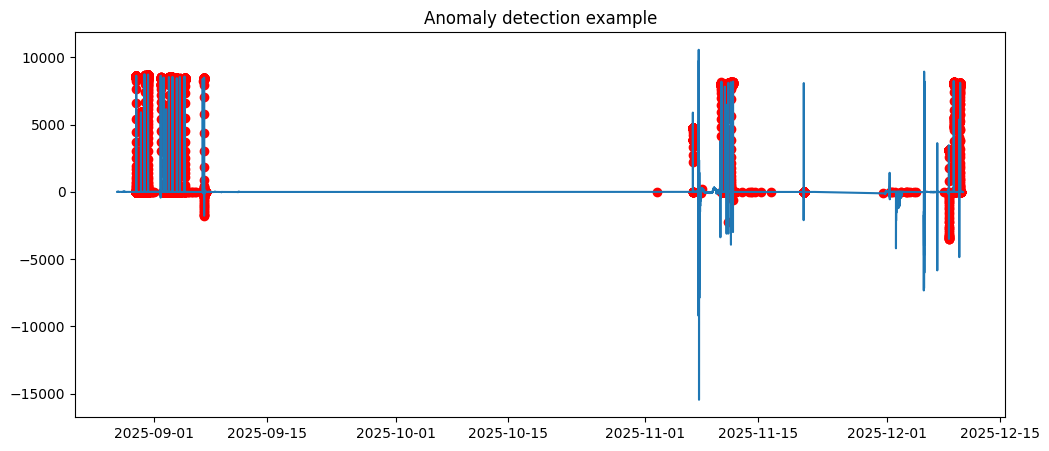

In [29]:
plt.figure(figsize=(12,5))
plt.plot(df_features.index, df_features.iloc[:,0])
plt.scatter(
    df_features[df_features["alarm"] == 1].index,
    df_features[df_features["alarm"] == 1].iloc[:,0],
    color="red"
)
plt.title("Anomaly detection example")
plt.show()


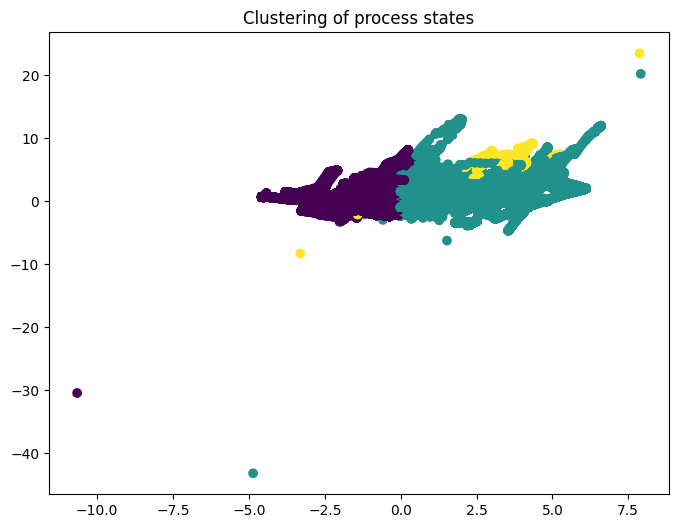

In [30]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Clustering of process states")
plt.show()


In [14]:

X = df_features.drop(["anomaly","alarm"], axis=1)
y = df_features["alarm"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Train score:", model.score(X_train, y_train))
print("Test score:", model.score(X_test, y_test))


Train score: 1.0
Test score: 0.9956136772203373


## SUPPRIMER LES COLONNES CONSTANTES

In [31]:
constant_cols = [col for col in df_features.columns if df_features[col].nunique() <= 1]

print("Colonnes constantes :", len(constant_cols))

df_features = df_features.drop(columns=constant_cols)
    

Colonnes constantes : 0


## SUPPRIMER LES COLONNES À FAIBLE VARIANCE

In [46]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=1e-4)  # seuil ajustable
X_var = selector.fit_transform(df_features.drop(["anomaly","alarm"], axis=1))

selected_features = df_features.drop(["anomaly","alarm"], axis=1).columns[selector.get_support()]

df_filtered = pd.DataFrame(X_var, index=df_features.index, columns=selected_features)

df_filtered["alarm"] = df_features["alarm"]


## SUPPRIMER LES COLONNES TROP CORRÉLÉES

In [47]:
corr_matrix = df_filtered.drop("alarm", axis=1).corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print("Colonnes très corrélées :", len(to_drop))

df_filtered = df_filtered.drop(columns=to_drop)


Colonnes très corrélées : 14


## TRAITEMENT DES CAPTEURS BINAIRE (VALVES)

In [48]:
binary_cols = [col for col in df_filtered.columns if df_filtered[col].nunique() <= 2]

for col in binary_cols:
    ratio = df_filtered[col].value_counts(normalize=True).max()
    if ratio > 0.99:
        df_filtered = df_filtered.drop(columns=[col])


In [49]:
df_filtered

Tag,826FQR23,826LR05,826LR06,826TRC07,826TRC07_DeltaT,826TRC08,826TRC08_DeltaT,826TRC09,826TRC09_DeltaT,826XV01,...,826XV16,826XV18,P-82601,826FQR23_diff,826LR05_diff,826LR06_diff,826TRC07_diff,826TRC07_DeltaT_diff,826TRC09_diff,alarm
Measure_Date,,,,,,,,,,,,,,,,,,,,,
2025-08-27 11:00:49,-3.87,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,0.20,0.0,0.00,0.0,0.0,0.0,0
2025-08-27 11:00:50,-3.89,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,-0.02,0.0,0.00,0.0,0.0,0.0,0
2025-08-27 11:00:51,-4.06,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,-0.17,0.0,0.00,0.0,0.0,0.0,0
2025-08-27 11:00:52,-4.12,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,-0.06,0.0,0.00,0.0,0.0,0.0,0
2025-08-27 11:00:53,-4.24,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,-0.12,0.0,0.00,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-10 11:01:46,-8.36,-0.04,51.95,24.85,0.0,60.97,0.02,24.18,0.01,0.0,...,0.0,1.0,0.0,-0.02,0.0,0.01,0.0,0.0,0.0,0
2025-12-10 11:01:47,-8.57,-0.04,51.95,24.85,0.0,60.97,0.02,24.18,0.01,0.0,...,0.0,1.0,0.0,-0.21,0.0,0.00,0.0,0.0,0.0,0
2025-12-10 11:01:48,-8.57,-0.04,51.95,24.85,0.0,60.97,0.02,24.18,0.01,0.0,...,0.0,1.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0


In [50]:
mapping_col = dict(zip(mapping['Instrument TAG ID'], mapping['Instrument Description']))
df_filtered.rename(columns=mapping_col, inplace=True)

print(df_filtered.head())

Tag                  Feed flow meter for all crystallizers  % of level  \
Measure_Date                                                             
2025-08-27 11:00:49                                  -3.87       -0.03   
2025-08-27 11:00:50                                  -3.89       -0.03   
2025-08-27 11:00:51                                  -4.06       -0.03   
2025-08-27 11:00:52                                  -4.12       -0.03   
2025-08-27 11:00:53                                  -4.24       -0.03   

Tag                  % of level  Temperature  Temperature ramp  Temperature  \
Measure_Date                                                                  
2025-08-27 11:00:49        1.13        25.93               0.0        25.72   
2025-08-27 11:00:50        1.13        25.93               0.0        25.72   
2025-08-27 11:00:51        1.13        25.93               0.0        25.72   
2025-08-27 11:00:52        1.13        25.93               0.0        25.72   
2025-08

In [51]:
df_filtered

Tag,Feed flow meter for all crystallizers,% of level,% of level,Temperature,Temperature ramp,Temperature,Temperature ramp,Temperature,Temperature ramp,Crystallizer bottom on/off valve,...,3-way supply valve,On/off power supply valve,P-82601,826FQR23_diff,826LR05_diff,826LR06_diff,826TRC07_diff,826TRC07_DeltaT_diff,826TRC09_diff,alarm
Measure_Date,,,,,,,,,,,,,,,,,,,,,
2025-08-27 11:00:49,-3.87,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,0.20,0.0,0.00,0.0,0.0,0.0,0
2025-08-27 11:00:50,-3.89,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,-0.02,0.0,0.00,0.0,0.0,0.0,0
2025-08-27 11:00:51,-4.06,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,-0.17,0.0,0.00,0.0,0.0,0.0,0
2025-08-27 11:00:52,-4.12,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,-0.06,0.0,0.00,0.0,0.0,0.0,0
2025-08-27 11:00:53,-4.24,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,-0.12,0.0,0.00,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-10 11:01:46,-8.36,-0.04,51.95,24.85,0.0,60.97,0.02,24.18,0.01,0.0,...,0.0,1.0,0.0,-0.02,0.0,0.01,0.0,0.0,0.0,0
2025-12-10 11:01:47,-8.57,-0.04,51.95,24.85,0.0,60.97,0.02,24.18,0.01,0.0,...,0.0,1.0,0.0,-0.21,0.0,0.00,0.0,0.0,0.0,0
2025-12-10 11:01:48,-8.57,-0.04,51.95,24.85,0.0,60.97,0.02,24.18,0.01,0.0,...,0.0,1.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0


In [55]:
mapping['Unique_Label'] = mapping['Instrument TAG ID'].astype(str) + " (" + mapping['Instrument Description'].astype(str) + ")"

mapping_unique = dict(zip(mapping['Instrument TAG ID'], mapping['Unique_Label']))

df_filtered.columns = [mapping_unique.get(col, col) for col in df_filtered.columns]

print("Nouveaux noms de colonnes :")
for col in df_filtered.columns:
    print(f"- {col}")

Nouveaux noms de colonnes :
- Feed flow meter for all crystallizers
- % of level
- % of level
- Temperature
- Temperature ramp
- Temperature
- Temperature ramp
- Temperature
- Temperature ramp
- Crystallizer bottom on/off valve
- Crystallizer bottom on/off valve
- 3-way supply valve
- On/off power supply valve
- P-82601
- 826FQR23_diff
- 826LR05_diff
- 826LR06_diff
- 826TRC07_diff
- 826TRC07_DeltaT_diff
- 826TRC09_diff
- alarm


In [56]:
df_filtered

,Feed flow meter for all crystallizers,% of level,% of level,Temperature,Temperature ramp,Temperature,Temperature ramp,Temperature,Temperature ramp,Crystallizer bottom on/off valve,...,3-way supply valve,On/off power supply valve,P-82601,826FQR23_diff,826LR05_diff,826LR06_diff,826TRC07_diff,826TRC07_DeltaT_diff,826TRC09_diff,alarm
Measure_Date,,,,,,,,,,,,,,,,,,,,,
2025-08-27 11:00:49,-3.87,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,0.20,0.0,0.00,0.0,0.0,0.0,0
2025-08-27 11:00:50,-3.89,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,-0.02,0.0,0.00,0.0,0.0,0.0,0
2025-08-27 11:00:51,-4.06,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,-0.17,0.0,0.00,0.0,0.0,0.0,0
2025-08-27 11:00:52,-4.12,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,-0.06,0.0,0.00,0.0,0.0,0.0,0
2025-08-27 11:00:53,-4.24,-0.03,1.13,25.93,0.0,25.72,0.00,25.45,0.00,1.0,...,1.0,1.0,1.0,-0.12,0.0,0.00,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-10 11:01:46,-8.36,-0.04,51.95,24.85,0.0,60.97,0.02,24.18,0.01,0.0,...,0.0,1.0,0.0,-0.02,0.0,0.01,0.0,0.0,0.0,0
2025-12-10 11:01:47,-8.57,-0.04,51.95,24.85,0.0,60.97,0.02,24.18,0.01,0.0,...,0.0,1.0,0.0,-0.21,0.0,0.00,0.0,0.0,0.0,0
2025-12-10 11:01:48,-8.57,-0.04,51.95,24.85,0.0,60.97,0.02,24.18,0.01,0.0,...,0.0,1.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0


In [58]:
X_cluster = df_filtered.drop("alarm", axis=1)

from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()
X_scaled_cluster = scaler_cluster.fit_transform(X_cluster)


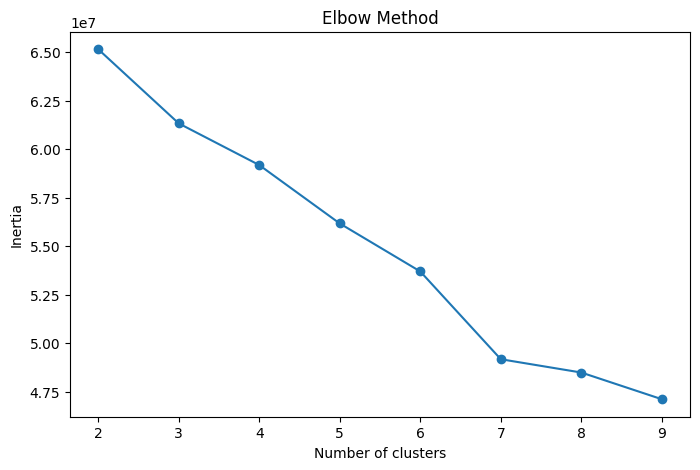

In [59]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled_cluster)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()


In [60]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled_cluster)

df_filtered["cluster"] = clusters


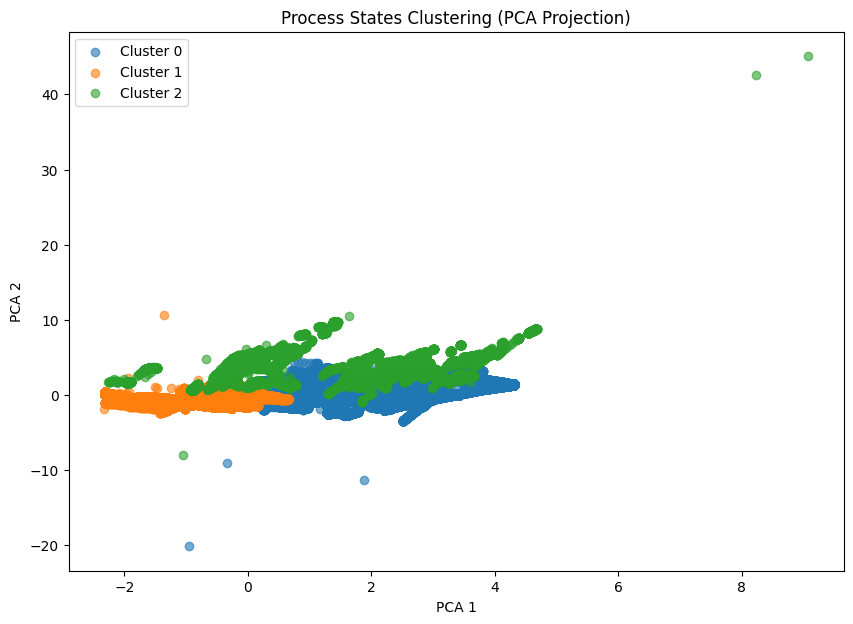

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_cluster)

plt.figure(figsize=(10,7))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]      
for i in range(3):
    plt.scatter(
        X_pca[clusters == i, 0],
        X_pca[clusters == i, 1],
        c=colors[i],
        label=f"Cluster {i}",
        alpha=0.6
    )

plt.title("Process States Clustering (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()


Cluster 0 → températures stables

Cluster 1 → variation élevée

Cluster 2 → dérive ou comportement anormal

In [62]:
df_filtered.groupby("cluster").mean()


,Feed flow meter for all crystallizers,% of level,% of level,Temperature,Temperature ramp,Temperature,Temperature ramp,Temperature,Temperature ramp,Crystallizer bottom on/off valve,...,3-way supply valve,On/off power supply valve,P-82601,826FQR23_diff,826LR05_diff,826LR06_diff,826TRC07_diff,826TRC07_DeltaT_diff,826TRC09_diff,alarm
cluster,,,,,,,,,,,,,,,,,,,,,
0,-15.313560,8.665984,19.469697,46.467382,-0.009574,44.137389,-0.005970,40.085014,0.001230,0.796260,...,0.719537,0.700639,0.761162,0.028853,-0.000112,-0.000169,-0.000172,-0.000022,0.000020,0.011277
1,-22.394627,1.904320,37.865500,26.730947,0.004613,21.755207,0.000932,24.570598,-0.007260,0.134907,...,0.851043,0.254203,0.224727,0.026361,-0.000270,0.000263,0.000070,-0.000011,-0.000126,0.000912
2,6219.651668,28.685664,28.871468,54.446670,1.607904,47.835039,0.737181,51.931008,0.538574,0.515716,...,0.523015,0.468212,0.572693,-5.243397,0.033712,0.023060,0.028596,0.004239,0.011195,0.494891
3,-10.461290,19.877758,16.813778,26.502661,-0.010214,24.757167,-0.000696,35.558369,-0.005927,0.158188,...,0.143227,0.195514,0.192044,0.014828,-0.000137,-0.000212,-0.000202,-0.000021,-0.000108,0.007177


In [70]:
df_filtered["826FQR23_diff"].describe()

count    3.799306e+06
mean    -1.184427e-06
std      1.483719e+01
min     -4.659050e+03
25%     -8.000000e-02
50%      0.000000e+00
75%      8.000000e-02
max      3.656350e+03
Name: 826FQR23_diff, dtype: float64

In [71]:
cluster_means = df_filtered.groupby("cluster").mean()

cluster_variance = cluster_means.var().sort_values(ascending=False)

cluster_variance.head(15)


Feed flow meter for all crystallizers    9.721038e+06
Temperature                              2.000723e+02
Temperature                              1.759988e+02
% of level                               1.408396e+02
Temperature                              1.282418e+02
% of level                               9.194235e+01
826FQR23_diff                            6.934685e+00
Temperature ramp                         6.504589e-01
Temperature ramp                         1.365731e-01
Crystallizer bottom on/off valve         1.308294e-01
Crystallizer bottom on/off valve         9.971770e-02
iso_anomaly                              9.519029e-02
3-way supply valve                       9.507458e-02
P-82601                                  7.618494e-02
Temperature ramp                         7.360674e-02
dtype: float64

In [72]:
df_filtered.groupby("cluster")["alarm"].mean()

cluster
0    0.011277
1    0.000912
2    0.494891
3    0.007177
Name: alarm, dtype: float64

In [73]:
df_filtered["cluster_shift"] = df_filtered["cluster"].shift(1)

transition_matrix = pd.crosstab(
    df_filtered["cluster_shift"],
    df_filtered["cluster"]
)

transition_matrix


cluster,0,1,2,3
cluster_shift,,,,
0.0,1785400,24,34,50
1.0,24,797329,47,20
2.0,35,43,17131,17
3.0,48,24,14,1199065


In [74]:
df_filtered["risk_state"] = df_filtered["cluster"].apply(
    lambda x: 1 if x == 2 else 0
)

In [75]:
df_filtered["future_alarm"] = df_filtered["alarm"].shift(-60)

In [79]:
Q1 = df_filtered['826FQR23_diff'].quantile(0.01)
Q99 = df_filtered['826FQR23_diff'].quantile(0.99)

df_filtered['826FQR23_diff'] = df_filtered['826FQR23_diff'].clip(Q1, Q99)


In [81]:
df_filtered['826FQR23_diff'].describe()

count    3.799306e+06
mean    -8.852944e-04
std      1.302130e-01
min     -3.800000e-01
25%     -8.000000e-02
50%      0.000000e+00
75%      8.000000e-02
max      3.600000e-01
Name: 826FQR23_diff, dtype: float64

In [82]:
df_filtered.groupby("cluster")["alarm"].mean()

cluster
0    0.011277
1    0.000912
2    0.494891
3    0.007177
Name: alarm, dtype: float64

In [83]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)


In [85]:
df_filtered[df_filtered['cluster']==2].index


DatetimeIndex(['2025-08-29 18:55:26', '2025-08-29 18:55:27',
               '2025-08-29 18:55:28', '2025-08-29 18:55:29',
               '2025-08-29 18:55:30', '2025-08-29 18:55:31',
               '2025-08-29 18:55:32', '2025-08-29 18:55:33',
               '2025-08-29 18:55:34', '2025-08-29 18:55:35',
               ...
               '2025-12-10 02:52:01', '2025-12-10 02:52:02',
               '2025-12-10 02:52:03', '2025-12-10 02:52:04',
               '2025-12-10 02:52:05', '2025-12-10 02:52:06',
               '2025-12-10 02:52:07', '2025-12-10 02:52:08',
               '2025-12-10 02:52:09', '2025-12-10 02:52:10'],
              dtype='datetime64[ns]', name='Measure_Date', length=17226, freq=None)

In [ ]:
from sklearn.ensemble import IsolationForest

X_anomaly = df_filtered.drop(["alarm", "cluster"], axis=1)

scaler_anomaly = StandardScaler()
X_scaled_anomaly = scaler_anomaly.fit_transform(X_anomaly)

iso = IsolationForest(
    contamination=0.01,  
    n_estimators=200,
    random_state=42
)

iso_pred = iso.fit_predict(X_scaled_anomaly)

df_filtered["iso_anomaly"] = np.where(iso_pred == -1, 1, 0)


In [64]:
from sklearn.metrics import classification_report

print(classification_report(
    df_filtered["alarm"],
    df_filtered["iso_anomaly"]
))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   3761312
           1       0.59      0.59      0.59     37994

    accuracy                           0.99   3799306
   macro avg       0.79      0.79      0.79   3799306
weighted avg       0.99      0.99      0.99   3799306



In [87]:
(df_filtered['cluster'] == 2).astype(int).groupby((df_filtered['cluster'] != 2).cumsum()).sum()


cluster
1          0
2          0
3          0
4          0
5          0
          ..
3782076    0
3782077    0
3782078    0
3782079    0
3782080    0
Name: cluster, Length: 3782080, dtype: int64

In [93]:
df_filtered['alarm_future'] = df_filtered['alarm'].shift(+600)  # 60 sec après


In [94]:
df_filtered.groupby('cluster')['alarm_future'].mean()

cluster
0    0.014406
1    0.000988
2    0.035354
3    0.009076
Name: alarm_future, dtype: float64

## Gestion du déséquilibre pour modèle supervisé

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df_filtered.drop(["alarm", "cluster", "iso_anomaly"], axis=1)
y = df_filtered["alarm"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

print("Train score:", model.score(X_train, y_train))
print("Test score:", model.score(X_test, y_test))


Train score: 1.0
Test score: 0.9941213009730714


In [66]:
from sklearn.metrics import confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))


[[755395      0]
 [  4467      0]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    755395
           1       0.00      0.00      0.00      4467

    accuracy                           0.99    759862
   macro avg       0.50      0.50      0.50    759862
weighted avg       0.99      0.99      0.99    759862

ROC AUC: 0.9940573253576745


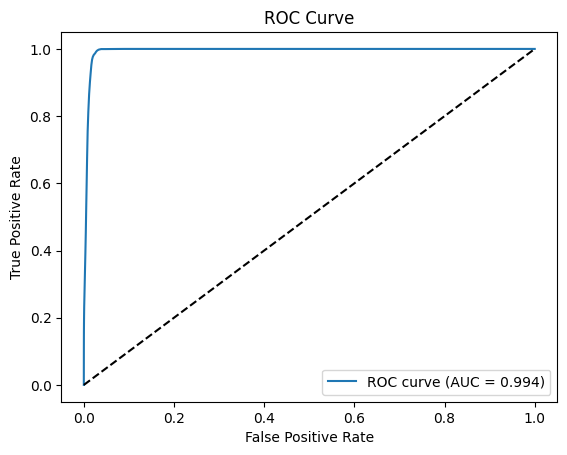

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


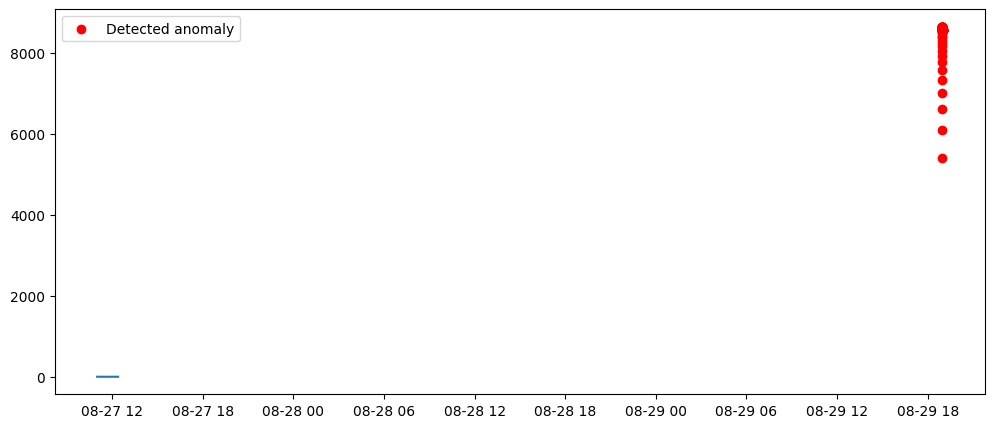

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df_filtered.index[:5000], df_filtered.iloc[:5000,0])

anomalies = df_filtered[df_filtered["iso_anomaly"] == 1].index

plt.scatter(
    anomalies[:200],
    df_filtered.loc[anomalies[:200]].iloc[:,0],
    color="red",
    label="Detected anomaly"
)

plt.legend()
plt.show()

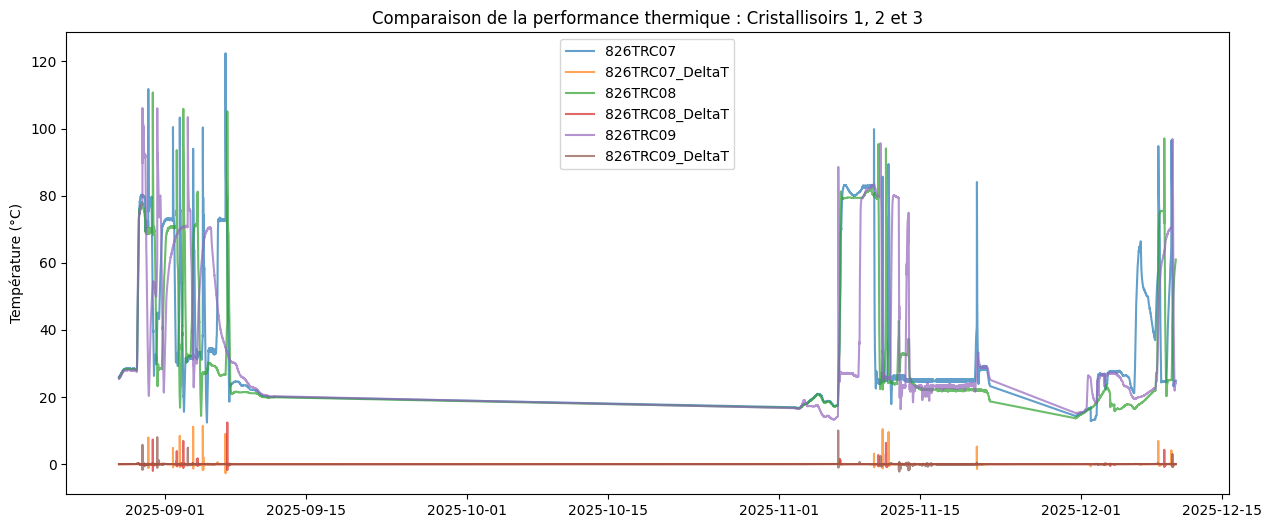

In [95]:
trc_cols = [col for col in df_pivot.columns if 'TRC' in col and 'ramp' not in col]

plt.figure(figsize=(15, 6))
for col in trc_cols:
    plt.plot(df_pivot.index, df_pivot[col], label=col, alpha=0.7)

plt.title('Comparaison de la performance thermique : Cristallisoirs 1, 2 et 3')
plt.ylabel('Température (°C)')
plt.legend()
plt.show()

## Clustering par machine

In [99]:
df_filtered.columns

Index(['Feed flow meter for all crystallizers', '% of level', '% of level',
       'Temperature', 'Temperature ramp', 'Temperature', 'Temperature ramp',
       'Temperature', 'Temperature ramp', 'Crystallizer bottom on/off valve',
       'Crystallizer bottom on/off valve', '3-way supply valve',
       'On/off power supply valve', 'P-82601', '826FQR23_diff', '826LR05_diff',
       '826LR06_diff', '826TRC07_diff', '826TRC07_DeltaT_diff',
       '826TRC09_diff', 'alarm', 'cluster', 'iso_anomaly', 'cluster_shift',
       'risk_state', 'future_alarm', 'alarm_future'],
      dtype='object')

In [101]:
from collections import Counter
Counter(df_filtered.columns)


Counter({'Temperature': 3,
         'Temperature ramp': 3,
         '% of level': 2,
         'Crystallizer bottom on/off valve': 2,
         'Feed flow meter for all crystallizers': 1,
         '3-way supply valve': 1,
         'On/off power supply valve': 1,
         'P-82601': 1,
         '826FQR23_diff': 1,
         '826LR05_diff': 1,
         '826LR06_diff': 1,
         '826TRC07_diff': 1,
         '826TRC07_DeltaT_diff': 1,
         '826TRC09_diff': 1,
         'alarm': 1,
         'cluster': 1,
         'iso_anomaly': 1,
         'cluster_shift': 1,
         'risk_state': 1,
         'future_alarm': 1,
         'alarm_future': 1})

In [107]:
cols = list(df_filtered.columns)

# exemple si les 3 températures sont index 3,5,7
cols[3] = 'Temp_M1'
cols[5] = 'Temp_M2'
cols[7] = 'Temp_M3'

# pareil pour ramp
cols[4] = 'TempRamp_M1'
cols[6] = 'TempRamp_M2'
cols[8] = 'TempRamp_M3'

df_filtered.columns = cols


In [108]:
features_m1 = [
    'Temp_M1',
    'TempRamp_M1',
    '% of level',  # si c'est celui de M1
]

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = df_filtered[features_m1].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
df_filtered.loc[X.index, 'cluster_M1'] = kmeans.fit_predict(X_scaled)


In [109]:
df_filtered.groupby('cluster_M1')['alarm'].mean()

cluster_M1
0.0    0.004290
1.0    0.014202
2.0    0.558460
3.0    0.024023
Name: alarm, dtype: float64

In [110]:
window_size = 300
step = 300

segments = []

for i in range(0, len(df_filtered)-window_size, step):
    segment = df_filtered['Temp_M1'].iloc[i:i+window_size].values
    segments.append(segment)

import numpy as np
segments = np.array(segments)


In [111]:
segments_norm = (segments - segments.mean(axis=1, keepdims=True)) / \
                segments.std(axis=1, keepdims=True)
